# Training a multilayer perceptron from scratch, in JAX

Build an MLP out of nothing but arrays — the parameters, the forward pass, the optimizers, and the training
loop. `jax.grad` gives you backpropagation; write everything else yourself.

The target is a sum of four sine waves of **equal amplitude** at frequencies 1, 2, 4 and 8. 

In [50]:
# !pip install -q jax jaxlib matplotlib

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.10.2 | devices: [CpuDevice(id=0)]


## The data


In [52]:
FREQS = jnp.array([1.0, 2.0, 4.0, 8.0])
NOISE_STD = 0.02


def target_fn(x):
    """x: (n,) -> (n,)"""
    return jnp.mean(jnp.sin(2 * jnp.pi * FREQS * x[:, None]), axis=-1)


def make_data(key, n=2048, noise_std=NOISE_STD):
    """Returns X: (n, 1), Y: (n, 1)"""
    key_x, key_noise = jax.random.split(key)
    x = jax.random.uniform(key_x, (n,), minval=0.0, maxval=1.0)
    y = target_fn(x) + noise_std * jax.random.normal(key_noise, (n,))
    return x[:, None], y[:, None]


X, Y = make_data(jax.random.key(0))

print(f"target variance : {float(Y.var()):.4f}")   # silly baseline: the error you get by predicting the mean

target variance : 0.1236


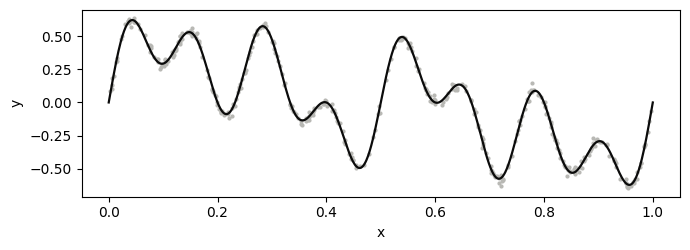

In [53]:
grid = jnp.linspace(0, 1, 1000)
plt.figure(figsize=(7, 2.6))
plt.scatter(np.array(X[:400, 0]), np.array(Y[:400, 0]), s=4, color="#b8b8b4")
plt.plot(np.array(grid), np.array(target_fn(grid)), color="#0b0b0b", lw=1.6)
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

---
## 1. The network

Write three functions:

- `init_mlp(key, layer_sizes)` — the parameters. Think about what a layer actually *is*, and about the scale
  of the initial random draw.
- `forward(params, x)` — `activation` on the hidden layers, nothing on the output.
- `loss_fn(params, x, y)` — mean squared error.

Use `[1, 128, 128, 1]`.

In [54]:
def init_mlp(key, layer_sizes):
    params = []

    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, subkey = jax.random.split(key)

        W = jax.random.normal(subkey, (n_in, n_out)) / jnp.sqrt(n_in)
        b = jnp.zeros(n_out)

        params.append((W, b))
    return params

params = init_mlp(jax.random.key(1), [1, 128, 128, 1])

for W, b in params:
    print("W:", W.shape, "b:", b.shape)

def forward(params, x):
    for W, b in params[:-1]:
        x = jnp.tanh(x @ W+b)

    W, b = params[-1]
    return x @ W+b

# testing a prediction to see how it works (no training yet)...
x_test = jnp.array([0.25])
print()
print("prediction:", forward(params, x_test))
print("target value:", target_fn(x_test))

def loss_fn(params, x, y):
    predictions = forward(params, x)
    return jnp.mean((predictions - y)**2)
print()
print("initial loss:", float(loss_fn(params, X, Y)))

# checking to make sure subtraction compares each prediction with its corresponding target
print(forward(params, X).shape, Y.shape)

W: (1, 128) b: (128,)
W: (128, 128) b: (128,)
W: (128, 1) b: (1,)

prediction: [-0.01299337]
target value: [0.25000012]

initial loss: 0.10451589524745941
(2048, 1) (2048, 1)


---
## 2. The training loop

Minibatches of 128, reshuffled every epoch, 400 epochs. Get gradients with `jax.grad`. Wrap the step in
`@jax.jit` or it will be slow.

before: 0.10451589524745941
after: 0.10433553904294968

epoch 50: loss = 0.060024
epoch 100: loss = 0.059603
epoch 150: loss = 0.058947
epoch 200: loss = 0.059019
epoch 250: loss = 0.060790
epoch 300: loss = 0.058446
epoch 350: loss = 0.058619
epoch 400: loss = 0.058614


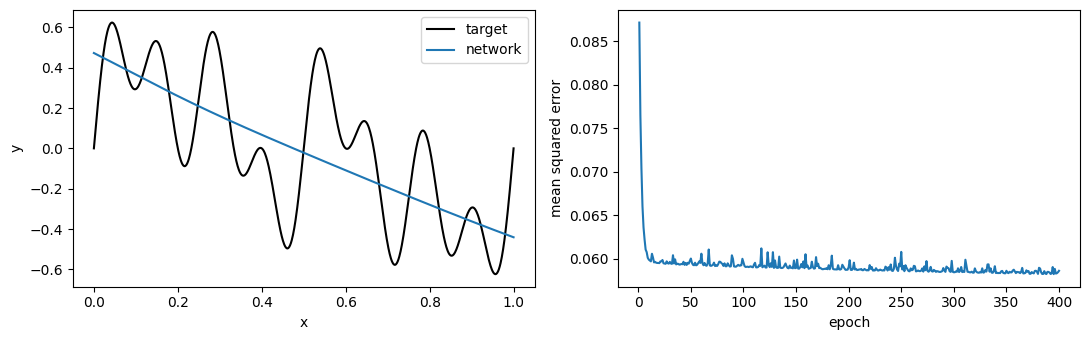

In [55]:
grads = jax.grad(loss_fn)(params, X, Y)

@jax.jit
def train_step(params, x, y, learning_rate):
    grads = jax.grad(loss_fn)(params, x, y)

    new_params = []
    for (W, b), (dW, db) in zip(params, grads):
        W_new = W - learning_rate * dW
        b_new = b - learning_rate * db
        new_params.append((W_new, b_new))
    return new_params

# rying one step using the full data set, with a small learning rate
print("before:", float(loss_fn(params, X, Y)))
params = train_step(params, X, Y, learning_rate=0.001)
print("after:", float(loss_fn(params, X, Y)))
print()

# 2 SGD minibatch full training loop
minibatch_size = 128
epochs = 400
learning_rate = 0.01

params = init_mlp(jax.random.key(1), [1, 128, 128, 1])
key = jax.random.key(2)
loss_history = []

for epoch in range(epochs):
    key, subkey = jax.random.split(key)
    order = jax.random.permutation(subkey, X.shape[0])

    X_shuffled = X[order]
    Y_shuffled = Y[order]

    for start in range(0, X.shape[0], minibatch_size):
        x_batch = X_shuffled[start:start + minibatch_size]
        y_batch = Y_shuffled[start:start + minibatch_size]

        params = train_step(params, x_batch, y_batch, learning_rate)

    loss = float(loss_fn(params, X, Y))
    loss_history.append(loss)

    if (epoch + 1) % 50 ==0:
        print(f"epoch {epoch + 1}: loss = {loss:.6f}")

# let's see what features it learned
grid = jnp.linspace(0, 1, 1000)
predictions = forward(params, grid[:, None])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(grid, target_fn(grid), color="black", label="target")
axes[0].plot(grid, predictions[:, 0], label="network")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(range(1, len(loss_history) + 1), loss_history)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean squared error")

plt.tight_layout(); plt.show()

In [56]:
params_sgd = params
loss_sgd = loss_history.copy()

---
## 3. The optimizers

Implement each one from its update equation:

1. **Gradient descent** — full batch, one step per epoch
2. **SGD** — minibatch
3. **SGD with momentum**
4. **Adagrad**
5. **Adam**
6. **Muon** — if you get that far, but it is waaaay trickier so don't get discouraged if you stop at Adam!

Look the update rules up. Muon is recent and not in textbooks:
[kellerjordan.github.io/posts/muon](https://kellerjordan.github.io/posts/muon/).

epoch 50: loss = 0.069310
epoch 100: loss = 0.061621
epoch 150: loss = 0.060002
epoch 200: loss = 0.059647
epoch 250: loss = 0.059545
epoch 300: loss = 0.059496
epoch 350: loss = 0.059460
epoch 400: loss = 0.059430


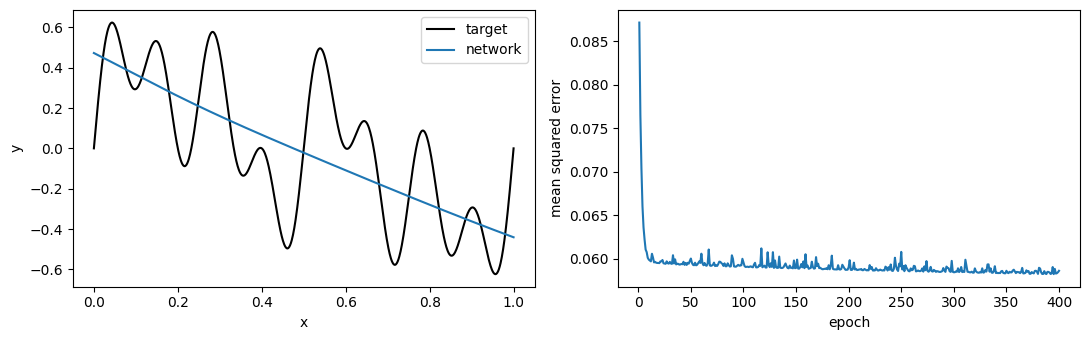

In [57]:
# 1 gradient descent
params_gd = init_mlp(jax.random.key(1), [1, 128, 128, 1])
loss_gd = []

for epoch in range(400):
    params_gd = train_step(params_gd, X, Y, learning_rate=0.01)

    loss = float(loss_fn(params_gd, X, Y))
    loss_gd.append(loss)

    if (epoch + 1) % 50 == 0:
        print(f"epoch {epoch + 1}: loss = {loss:.6f}")


params_gd = params
loss_gd = loss_history.copy()

grid = jnp.linspace(0, 1, 1000)
predictions = forward(params, grid[:, None])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(grid, target_fn(grid), color="black", label="target")
axes[0].plot(grid, predictions[:, 0], label="network")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(range(1, len(loss_history) + 1), loss_history)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean squared error")

plt.tight_layout(); plt.show()

epoch 50: loss = 0.059442
epoch 100: loss = 0.060149
epoch 150: loss = 0.058964
epoch 200: loss = 0.058732
epoch 250: loss = 0.058810
epoch 300: loss = 0.058446
epoch 350: loss = 0.058401
epoch 400: loss = 0.058366


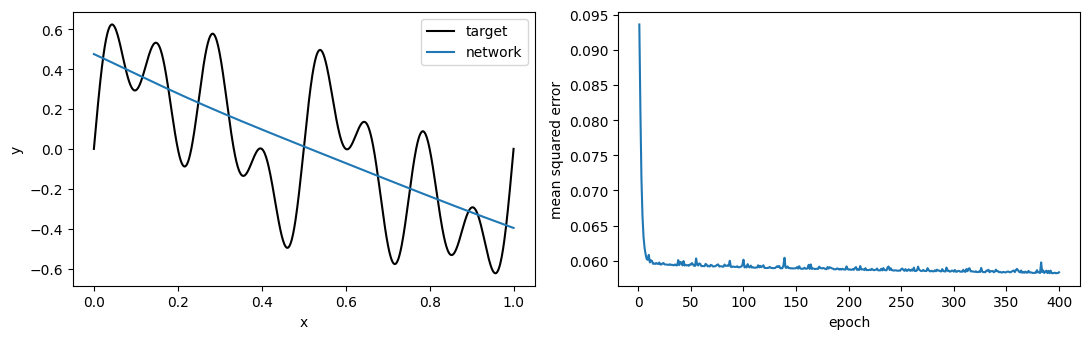

In [58]:
# 3 SGD with momentum
@jax.jit
def momentum_step(params, velocities, x, y, learning_rate):
    grads = jax.grad(loss_fn)(params, x, y)

    new_params = []
    new_velocities = []

    for (W, b), (vW, vb), (dW, db) in zip(params, velocities, grads):
        vW = 0.9 * vW + dW
        vb = 0.9 * vb + db

        W = W - learning_rate*vW
        b = b - learning_rate*vb

        new_params.append((W, b))
        new_velocities.append((vW, vb))
    return new_params, new_velocities

params = init_mlp(jax.random.key(1), [1, 128, 128, 1])
velocities = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params]

key = jax.random.key(2)
learning_rate = 0.001
minibatch_size = 128
epochs = 400
loss_history = []

for epoch in range(epochs):
    key, subkey = jax.random.split(key)
    order = jax.random.permutation(subkey, X.shape[0])

    X_shuffled = X[order]
    Y_shuffled = Y[order]

    for start in range(0, X.shape[0], minibatch_size):
        x_batch = X_shuffled[start:start + minibatch_size]
        y_batch = Y_shuffled[start:start + minibatch_size]

        params, velocities = momentum_step(params, velocities, x_batch, y_batch, learning_rate)

    loss = float(loss_fn(params, X, Y))
    loss_history.append(loss)

    if (epoch + 1) % 50 == 0:
        print(f"epoch {epoch + 1}: loss = {loss:.6f}")

params_momentum = params
loss_momentum = loss_history.copy()


grid = jnp.linspace(0, 1, 1000)
predictions = forward(params, grid[:, None])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(grid, target_fn(grid), color="black", label="target")
axes[0].plot(grid, predictions[:, 0], label="network")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(range(1, len(loss_history) + 1), loss_history)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean squared error")

plt.tight_layout(); plt.show()

epoch 50: loss = 0.062552
epoch 100: loss = 0.059777
epoch 150: loss = 0.058438
epoch 200: loss = 0.058827
epoch 250: loss = 0.060323
epoch 300: loss = 0.057794
epoch 350: loss = 0.058220
epoch 400: loss = 0.058342


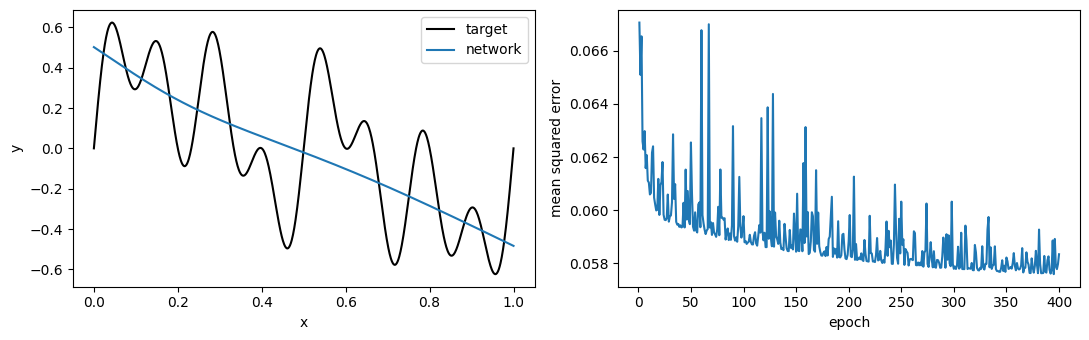

In [59]:
# 4 Adagrad
@jax.jit

def adagrad_step(params, accumulators, x, y, learning_rate):
    grads = jax.grad(loss_fn)(params, x, y,)

    new_params = []
    new_accumulators = []

    for (W, b), (sW, sb), (dW, db) in zip(params, accumulators, grads):
        sW = sW + dW**2
        sb = sb + db**2

        W = W - learning_rate * dW / (jnp.sqrt(sW) + 1e-8)
        b = b - learning_rate * db / (jnp.sqrt(sb) + 1e-8)

        new_params.append((W, b))
        new_accumulators.append((sW, sb))

    return new_params, new_accumulators

params = init_mlp(jax.random.key(1), [1, 128, 128, 1])
accumulators = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params]

key = jax.random.key(2)
learning_rate = 0.01
minibatch_size = 128
epochs = 400
loss_history = []

for epoch in range(epochs):
    key, subkey = jax.random.split(key)
    order = jax.random.permutation(subkey, X.shape[0])

    X_shuffled = X[order]
    Y_shuffled = Y[order]

    for start in range(0, X.shape[0], minibatch_size):
        x_batch = X_shuffled[start:start + minibatch_size]
        y_batch = Y_shuffled[start:start + minibatch_size]

        params, accumulators = adagrad_step(params, accumulators, x_batch, y_batch, learning_rate)

    loss = float(loss_fn(params, X, Y))
    loss_history.append(loss)

    if (epoch + 1) % 50 == 0:
        print(f"epoch {epoch + 1}: loss = {loss:.6f}")

params_adagrad = params
loss_adagrad = loss_history.copy()    
                 
grid = jnp.linspace(0, 1, 1000)
predictions = forward(params, grid[:, None])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(grid, target_fn(grid), color="black", label="target")
axes[0].plot(grid, predictions[:, 0], label="network")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(range(1, len(loss_history) + 1), loss_history)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean squared error")

plt.tight_layout(); plt.show()


epoch 50: loss = 0.058107
epoch 100: loss = 0.058252
epoch 150: loss = 0.056688
epoch 200: loss = 0.057717
epoch 250: loss = 0.057555
epoch 300: loss = 0.048575
epoch 350: loss = 0.032927
epoch 400: loss = 0.022530


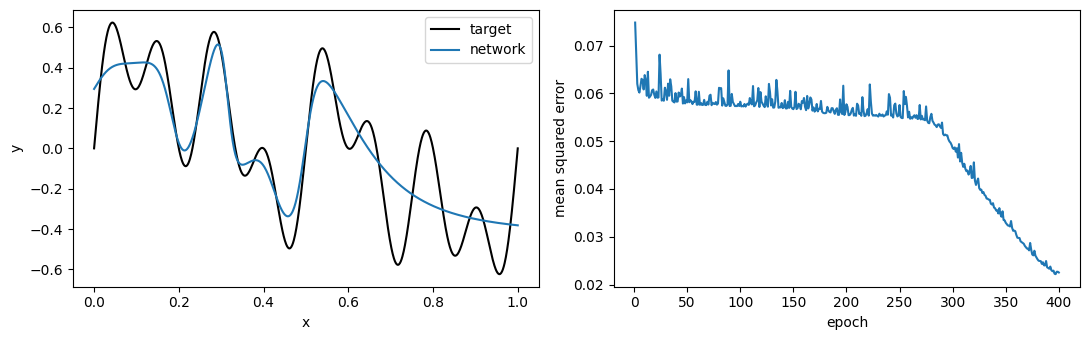

In [60]:
# 5 Adam

@jax.jit
def adam_step(params, m, v, x, y, t, learning_rate):
    grads = jax.grad (loss_fn)(params, x, y)

    new_params = []
    new_m = []
    new_v = []

    for (W, b), (mW, mb), (vW, vb), (dW, db) in zip(params, m, v, grads):
        mW=0.9*mW+0.1*dW    # moving averages
        mb=0.9*mb+0.1*db
        vW=0.999*vW+0.001*dW**2
        vb=0.999*vb+0.001*db**2
                            # bias correction
        mW_hat = mW / (1- 0.9**t)
        mb_hat = mb / (1- 0.9**t)
        vW_hat = vW / (1- 0.999**t)
        vb_hat = vb / (1- 0.999**t)
                            # parameter updates
        W = W - learning_rate * mW_hat / (jnp.sqrt(vW_hat)+1e-8)
        b = b - learning_rate * mb_hat / (jnp.sqrt(vb_hat)+1e-8)

        new_params.append((W, b))
        new_m.append((mW, mb))
        new_v.append((vW, vb))

    return new_params, new_m, new_v

params = init_mlp(jax.random.key(1), [1, 128, 128, 1])
m = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params]
v = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params]

key = jax.random.key(2)
learning_rate = 0.001
minibatch_size = 128
epochs = 400
t = 0
loss_history = []

for epoch in range(epochs):
    key, subkey = jax.random.split(key)
    order = jax.random.permutation(subkey, X.shape[0])

    X_shuffled = X[order]
    Y_shuffled = Y[order]

    for start in range(0, X.shape[0], minibatch_size):
        x_batch = X_shuffled[start:start + minibatch_size]
        y_batch = Y_shuffled[start:start + minibatch_size]

        t += 1
        params, m, v = adam_step(params, m, v, x_batch, y_batch, t, learning_rate)

    loss = float(loss_fn(params, X, Y))
    loss_history.append(loss)

    if (epoch + 1) % 50 == 0:
        print(f"epoch {epoch + 1}: loss = {loss:.6f}")

params_adam = params
loss_adam = loss_history.copy()    
                 
grid = jnp.linspace(0, 1, 1000)
predictions = forward(params, grid[:, None])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(grid, target_fn(grid), color="black", label="target")
axes[0].plot(grid, predictions[:, 0], label="network")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(range(1, len(loss_history) + 1), loss_history)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean squared error")

plt.tight_layout(); plt.show()



---
## 4. What to report

- **All six loss curves on one set of axes**, log scale on y. Plot against both epochs and steps

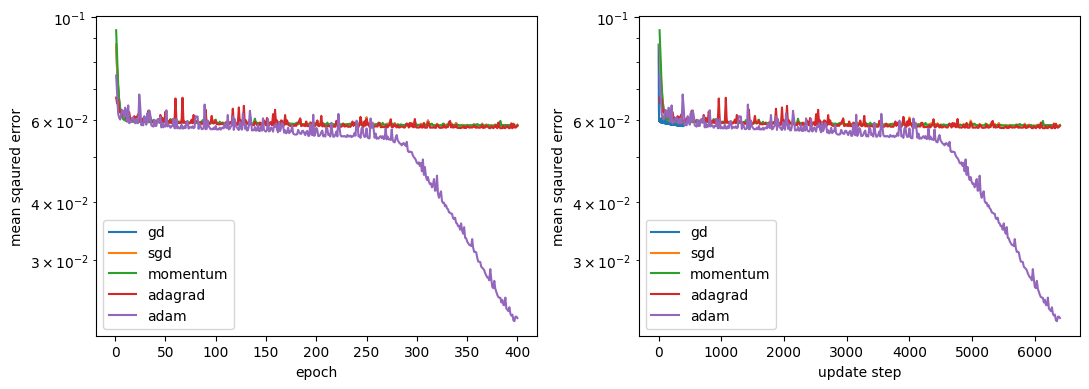

In [67]:
histories = {
    "gd": loss_gd,
    "sgd": loss_sgd,
    "momentum": loss_momentum,
    "adagrad": loss_adagrad,
    "adam": loss_adam,
}

fig, axes = plt.subplots(1, 2, figsize=(11,4))

for name, losses in histories.items():
    epoch_numbers = np.arange(1, len(losses) + 1)
    steps_per_epoch = 1 if name == "gd" else 16

    axes[0].semilogy(epoch_numbers, losses, label=name)
    axes[1].semilogy(epoch_numbers * steps_per_epoch, losses, label=name)
    
axes[0].set_xlabel("epoch")
axes[1].set_xlabel("update step")

for ax in axes:
    ax.set_ylabel("mean sqaured error")
    ax.legend()

plt.tight_layout() ; plt.show()
    

---
## 5. One more plot

Now make a plot I did not ask for.



epoch 450: loss = 0.018251
epoch 500: loss = 0.016767
epoch 550: loss = 0.016765
epoch 600: loss = 0.016335
epoch 650: loss = 0.017153
epoch 700: loss = 0.016096
epoch 750: loss = 0.015873
epoch 800: loss = 0.012824
epoch 850: loss = 0.005193
epoch 900: loss = 0.003890
epoch 950: loss = 0.004027
epoch 1000: loss = 0.003656
epoch 1050: loss = 0.003592
epoch 1100: loss = 0.003545
epoch 1150: loss = 0.003627
epoch 1200: loss = 0.003601


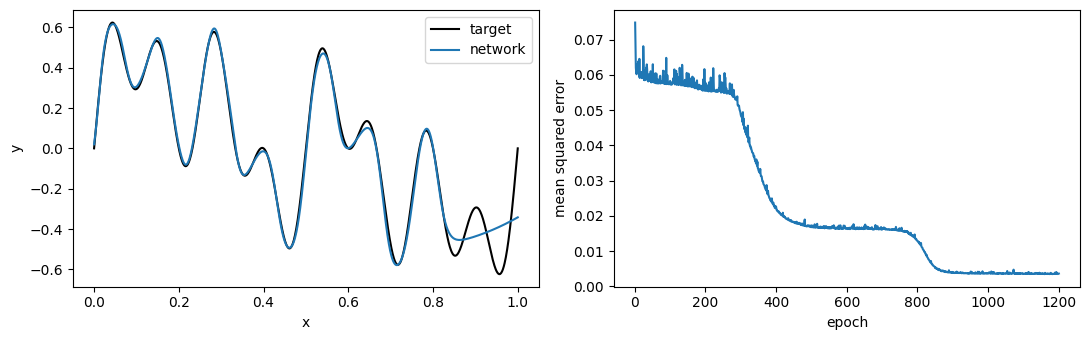

In [61]:
# running Adam for 800 epochs

start_epoch = len(loss_history)

for epoch in range(start_epoch, start_epoch + 800):
    key, subkey = jax.random.split(key)
    order = jax.random.permutation(subkey, X.shape[0])

    X_shuffled = X[order]
    Y_shuffled = Y[order]

    for start in range(0, X.shape[0], minibatch_size):
        x_batch = X_shuffled[start:start + minibatch_size]
        y_batch = Y_shuffled[start:start + minibatch_size]

        t += 1
        params, m, v = adam_step(params, m, v, x_batch, y_batch, t, learning_rate)

    loss = float(loss_fn(params, X, Y))
    loss_history.append(loss)

    if (epoch + 1) % 50 == 0:
        print(f"epoch {epoch + 1}: loss = {loss:.6f}")

params_adam_800 = params
loss_adam_800 = loss_history.copy()    
                 
grid = jnp.linspace(0, 1, 1000)
predictions = forward(params, grid[:, None])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(grid, target_fn(grid), color="black", label="target")
axes[0].plot(grid, predictions[:, 0], label="network")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(range(1, len(loss_history) + 1), loss_history)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean squared error")

plt.tight_layout(); plt.show()

    